In [76]:
import uproot
import numpy as np
file=uproot.open("output_wpotential_wcoll_offshell_ccqe_plus_deltas/jg_test_NIWG_dnn.root")

tree = file['NIWGTree']

# Read necessary branches once
nu_index = tree['NIWGEvent/nu_index'].array()
isnuc_index = tree['NIWGEvent/isnuc_index'].array()
fslep_index = tree['NIWGEvent/fslep_index'].array()
Q2_array = tree['NIWGEvent/Q2'].array()
p_array = tree['NIWGEvent/part_stack/part_stack.p'].array()

# Split momentum and energy
fE = p_array['fE']
fPx = p_array['fP']['fX']
fPy = p_array['fP']['fY']
fPz = p_array['fP']['fZ']

mN = 0.938  # Nucleon mass

def moma(idx, j):
    return np.array([
        fE[j, idx],
        fPx[j, idx],
        fPy[j, idx],
        fPz[j, idx]
    ])

def invariant_mass(vec1, vec2, vec3):
    total = vec1 - vec2 + vec3
    return np.sqrt(total[0]*total[0]-total[1]*total[1]-total[2]*total[2]-total[3]*total[3])
nu_idx = nu_index[4]
nuc_idx = isnuc_index[4]
lep_idx = fslep_index[4]
W = invariant_mass(moma(nu_idx, 4), moma(lep_idx, 4), moma(nuc_idx, 4))
W,moma(nu_idx, 4), moma(lep_idx, 4), moma(nuc_idx, 4)

(np.float64(1.203687648670635),
 array([0.63281378, 0.        , 0.        , 0.63281378]),
 array([ 0.2316012 , -0.1913535 , -0.07609688,  0.00828287]),
 array([ 0.96266828, -0.18439668,  0.1106882 , -0.01104091]))

In [77]:
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
# file=uproot.open("output_wpotential_wcoll+cuts/jg_merged_wp.root")
file3=uproot.open("output_wpotential_wcoll_offshell_ccqe_plus_deltas/jg_FinalEvents_w_med.root")
file=uproot.open("output_wpotential_wcoll_wo_offshell_ccqe_plus_deltas/jg_FinalEvents_wo_med.root")

file2=uproot.open("output_wpotential_wcoll_offshell_ccqe_plus_deltas/jg_test_NIWG_dnn.root")

mode=file2['NIWGTree']['NIWGEvent/neutmode'].array() ## interaction mode
targetA=file2['NIWGTree']['NIWGEvent/targetA'].array()## C in our case
Nprimary=file2['NIWGTree']['NIWGEvent/NPrimary'].array() ## number of particles in primary interaction
Nupdg=file2['NIWGTree']['NIWGEvent/NuPDG'].array() ##  numu beam
truenuE=file2['NIWGTree']['NIWGEvent/TrueEnu'].array() ## fixed energy beam
Q2=file2['NIWGTree']['NIWGEvent/Q2'].array() ## Q2
q3=file2['NIWGTree']['NIWGEvent/q3'].array() ## q3
q0=file2['NIWGTree']['NIWGEvent/q0'].array() ## q0
W=file2['NIWGTree']['NIWGEvent/W'].array() ## W
Emiss=file2['NIWGTree']['NIWGEvent/Emiss'].array() ## missing energy E
Pmiss=file2['NIWGTree']['NIWGEvent/Pmiss'].array() ## missing momentum p
weight=file2['NIWGTree']['NIWGEvent/weight'].array() ## weight
px=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.p'].array()[:]['fP']['fX']
py=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.p'].array()[:]['fP']['fY']
pz=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.p'].array()[:]['fP']['fZ']
E=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.p'].array()[:]['fE']
pdg=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.pdg'].array()
chase=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.chase'].array() ## whther the particle is alive or not
parent=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.parent'].array() ## parent
isatPV=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.isAtPrimaryVertex'].array() ## parent
angle=file2['NIWGTree']['NIWGEvent/theta_partToNu'].array()
nuindex=file2['NIWGTree']['NIWGEvent/nu_index'].array()
nucindex=file2['NIWGTree']['NIWGEvent/isnuc_index'].array()
flesp_index=file2['NIWGTree']['NIWGEvent/fslep_index'].array() ## Some useful particle stack indicies to pre-calculate
###############################################################
incident_counter_wo_med=file['Events;1']['incident'].array()
px_gibuu_wo_med=file['Events;1']['momX'].array()
py_gibuu_wo_med=file['Events;1']['momY'].array()
pz_gibuu_wo_med=file['Events;1']['momZ'].array()
E_gibuu_wo_med=file['Events;1']['momE'].array()
ID_gibuu_wo_med=file['Events;1']['ID'].array()
charge_gibuu_wo_med=file['Events;1']['Charge'].array()
history_gibuu_wo_med=file['Events;1']['history'].array()
prodid_gibuu_wo_med=file['Events;1']['prod_id'].array()
incident_counter_gibuu_wo_med1=ak.Array([incident_counter_wo_med[i] for i in range(len(incident_counter_wo_med)) if len(prodid_gibuu_wo_med[i])>2])

###################################################################
incident_counter_w_med=file3['Events;1']['incident'].array()
px_gibuu_w_med=file3['Events;1']['momX'].array()
py_gibuu_w_med=file3['Events;1']['momY'].array()
pz_gibuu_w_med=file3['Events;1']['momZ'].array()
E_gibuu_w_med=file3['Events;1']['momE'].array()
ID_gibuu_w_med=file3['Events;1']['ID'].array()
charge_gibuu_w_med=file3['Events;1']['Charge'].array()
history_gibuu_w_med=file3['Events;1']['history'].array()
prodid_gibuu_w_med=file3['Events;1']['prod_id'].array()
incident_counter_gibuu_w_med1=ak.Array([incident_counter_w_med[i] for i in range(len(incident_counter_w_med)) if len(prodid_gibuu_w_med[i])>2])
np.intersect1d(incident_counter_gibuu_wo_med1, incident_counter_gibuu_w_med1, return_indices=True)[1]# len(targetA),len(incident_counter_w_med),len(incident_counter_w_med)
# print(np.intersect1d(incident_counter_w_med,incident_counter_wo_med))
# print(len(np.intersect1d(incident_counter_w_med,incident_counter_wo_med)))

<Array [0, 1, 2, 3, 4, ..., 76419, 76420, 76421, 76422] type='74028 * int64'>

In [55]:
history_gibuu_wo_med

<Array [[0, 0, 1000002, 1000002], ..., [0, ..., 0]] type='76435 * var * int64'>

In [56]:
idx1, idx, idx2 = np.intersect1d(incident_counter_gibuu_wo_med1, incident_counter_gibuu_w_med1, return_indices=True)

idx=incident_counter_gibuu_wo_med1[idx]
idx2=incident_counter_gibuu_w_med1[idx2]
idx2

<Array [1, 2, 3, 4, 5, ..., 79997, 79998, 79999, 80000] type='74028 * int64'>

In [57]:
pdg

<Array [[14, 2112, 13, 2212], ..., [14, ..., 211]] type='500000 * var * int32'>

In [58]:
history_gibuu_w_med

<Array [[0, 0, 1000002, 1000002], ..., [0, ..., 0]] type='76480 * var * int64'>

In [59]:
idx1, idx, idx2 = np.intersect1d(incident_counter_gibuu_wo_med1, incident_counter_gibuu_w_med1, return_indices=True)
idx=incident_counter_gibuu_wo_med1[idx]
idx2=incident_counter_gibuu_w_med1[idx2]

_, _, idx = np.intersect1d(idx, incident_counter_wo_med, return_indices=True)
_, _, idx2 = np.intersect1d(idx2, incident_counter_w_med, return_indices=True)

pdgf=ak.flatten(pdg[idx1])
chasef=ak.flatten(chase[idx1])
Ef=ak.flatten(E[idx1])
Pxf=ak.flatten(px[idx1])
Pyf=ak.flatten(py[idx1])
Pzf=ak.flatten(pz[idx1])
Ptf=np.sqrt(Pxf**2+Pyf**2)
Costhetaf=Pzf/np.sqrt(Pxf**2+Pyf**2+Pzf**2)
################################
pdgf_gibuu_wo_med=ak.flatten(ID_gibuu_wo_med[:,2:][idx])
chargef_gibuu_wo_med=ak.flatten(charge_gibuu_wo_med[:,2:][idx])
historyf_gibuu_wo_med=ak.flatten(history_gibuu_wo_med[:,2:][idx])

pxf_gibuu_wo_med=ak.flatten(px_gibuu_wo_med[:,2:][idx])
pyf_gibuu_wo_med=ak.flatten(py_gibuu_wo_med[:,2:][idx])
pzf_gibuu_wo_med=ak.flatten(pz_gibuu_wo_med[:,2:][idx])
ptf_gibuu_wo_med=np.sqrt(pxf_gibuu_wo_med**2+pyf_gibuu_wo_med**2)

Ef_gibuu_wo_med=ak.flatten(E_gibuu_wo_med[:,2:][idx])
costheta_wo_med=pzf_gibuu_wo_med/np.sqrt(pxf_gibuu_wo_med*pxf_gibuu_wo_med+pyf_gibuu_wo_med*pyf_gibuu_wo_med+pzf_gibuu_wo_med*pzf_gibuu_wo_med)
costheta_wo_med[costheta_wo_med<=np.cos(np.pi)]
################################
pdgf_gibuu_w_med=ak.flatten(ID_gibuu_w_med[:,2:][idx2])
chargef_gibuu_w_med=ak.flatten(charge_gibuu_w_med[:,2:][idx2])
historyf_gibuu_w_med=ak.flatten(history_gibuu_w_med[:,2:][idx2])
pxf_gibuu_w_med=ak.flatten(px_gibuu_w_med[:,2:][idx2])
pyf_gibuu_w_med=ak.flatten(py_gibuu_w_med[:,2:][idx2])
pzf_gibuu_w_med=ak.flatten(pz_gibuu_w_med[:,2:][idx2])
ptf_gibuu_w_med=np.sqrt(pxf_gibuu_w_med**2+pyf_gibuu_w_med**2)

Ef_gibuu_w_med=ak.flatten(E_gibuu_w_med[:,2:][idx2])
costheta_w_med=pzf_gibuu_w_med/np.sqrt(pxf_gibuu_w_med*pxf_gibuu_w_med+pyf_gibuu_w_med*pyf_gibuu_w_med+pzf_gibuu_w_med*pzf_gibuu_w_med)
costheta_w_med[costheta_w_med<=np.cos(np.pi)]

<Array [] type='0 * float64'>

Text(0, 0.5, 'Counts')

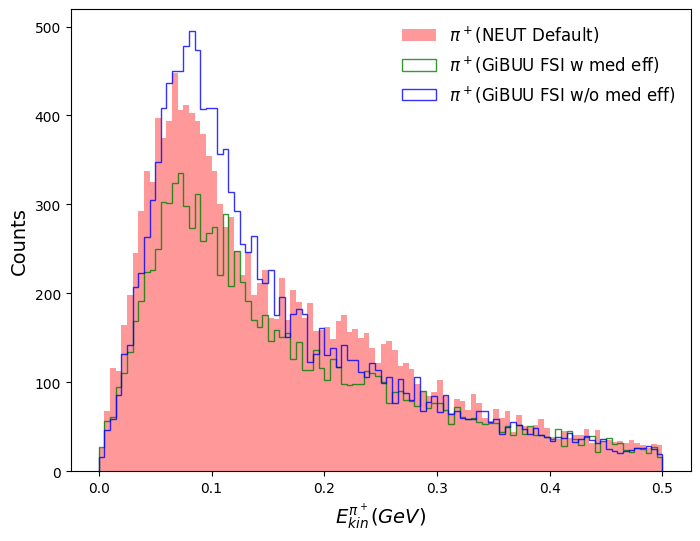

In [60]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot()
ax.hist(Ef[np.logical_and.reduce((pdgf==211,chasef==1))]-0.13957,bins=100,color="red",alpha=0.4, label=r"$\pi^+$(NEUT Default)",range=(0,0.5))
# costheta_cutpi_neut=Costhetaf[np.logical_and.reduce((pdgf==111,chasef==1))]


eg_cutpi_wo_med=Ef_gibuu_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==101,chargef_gibuu_wo_med==1))]-0.13957
costheta_cutpi_wo_med=costheta_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==101,chargef_gibuu_wo_med==1))]-0.13957
# costheta_cutn_w_med=costheta_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==0))]
###############################
###############################
eg_cutpi_w_med=Ef_gibuu_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==101,chargef_gibuu_w_med==1))]-0.13957
costheta_cutpi_w_med=costheta_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==101,chargef_gibuu_w_med==1))]-0.13957
# costheta_cutn_w_med=costheta_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==0))]
###############################
# ax.hist(eg_cutp[np.logical_and.reduce((eg_cutp>0.00,costheta_cutp>=np.cos(np.pi)))],bins=100,color="red",alpha=0.4,histtype='step',label="p(GiBUU FSI)")
# ax.hist(eg_cutn[np.logical_and.reduce((eg_cutn>0.00,costheta_cutn>=np.cos(np.pi)))],bins=100,color="blue",alpha=0.4,histtype='step', label="n(GiBUU FSI)")
ax.hist(eg_cutpi_w_med[eg_cutpi_w_med>0.00],bins=100,color="green",alpha=0.8,histtype='step',label=r"$\pi^+$(GiBUU FSI w med eff)",range=(0,0.5))
ax.hist(eg_cutpi_wo_med[eg_cutpi_wo_med>0.00],bins=100,color="blue",alpha=0.8,histtype='step',label=r"$\pi^+$(GiBUU FSI w/o med eff)",range=(0,0.5))

# ax.hist(eg_cutn_w_med[np.logical_and.reduce((eg_cutn_w_med>-100.00,costheta_cutn_w_med>=np.cos(np.pi)))],bins=100,color="brown",alpha=0.8,histtype='step', label="n(GiBUU FSI w med eff)",range=(0,0.5))
plt.legend(fontsize=12,framealpha=0.0)
plt.xlabel(r"$E_{kin}^{\pi^+} (GeV)$",fontsize=14)
plt.ylabel(r"Counts",fontsize=14)
# plt.savefig("jg_plots_300725/EkinH_gibuufsi_vs_neut.png")

Text(0, 0.5, 'Counts')

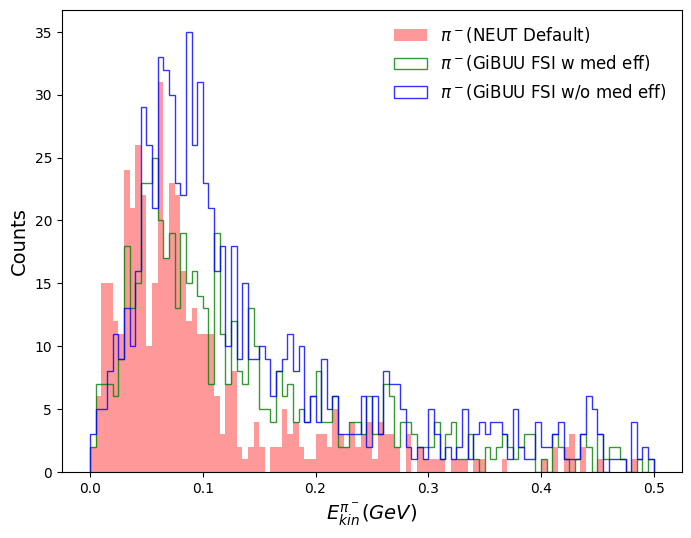

In [61]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot()
ax.hist(Ef[np.logical_and.reduce((pdgf==-211,chasef==1))]-0.13957,bins=100,color="red",alpha=0.4, label=r"$\pi^-$(NEUT Default)",range=(0,0.5))
costheta_cutpi_neut=Costhetaf[np.logical_and.reduce((pdgf==111,chasef==1))]

###############################
eg_cutpi_w_med=Ef_gibuu_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==101,chargef_gibuu_w_med==-1))]-0.13957
costheta_cutpi_w_med=costheta_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==101,chargef_gibuu_w_med==-1))]-0.13957
eg_cutpi_wo_med=Ef_gibuu_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==101,chargef_gibuu_wo_med==-1))]-0.13957
costheta_cutpi_wo_med=costheta_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==101,chargef_gibuu_wo_med==-1))]-0.13957
# costheta_cutn_w_med=costheta_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==0))]
###############################
# ax.hist(eg_cutp[np.logical_and.reduce((eg_cutp>0.00,costheta_cutp>=np.cos(np.pi)))],bins=100,color="red",alpha=0.4,histtype='step',label="p(GiBUU FSI)")
# ax.hist(eg_cutn[np.logical_and.reduce((eg_cutn>0.00,costheta_cutn>=np.cos(np.pi)))],bins=100,color="blue",alpha=0.4,histtype='step', label="n(GiBUU FSI)")
ax.hist(eg_cutpi_w_med[eg_cutpi_w_med>0.00],bins=100,color="green",alpha=0.8,histtype='step',label=r"$\pi^-$(GiBUU FSI w med eff)",range=(0,0.5))
ax.hist(eg_cutpi_wo_med[eg_cutpi_wo_med>0.00],bins=100,color="blue",alpha=0.8,histtype='step',label=r"$\pi^-$(GiBUU FSI w/o med eff)",range=(0,0.5))

# ax.hist(eg_cutn_w_med[np.logical_and.reduce((eg_cutn_w_med>-100.00,costheta_cutn_w_med>=np.cos(np.pi)))],bins=100,color="brown",alpha=0.8,histtype='step', label="n(GiBUU FSI w med eff)",range=(0,0.5))
plt.legend(fontsize=12,framealpha=0.0)
plt.xlabel(r"$E_{kin}^{\pi^-} (GeV)$",fontsize=14)
plt.ylabel(r"Counts",fontsize=14)
# plt.savefig("jg_plots_300725/EkinH_gibuufsi_vs_neut.png")

Text(0, 0.5, 'Counts')

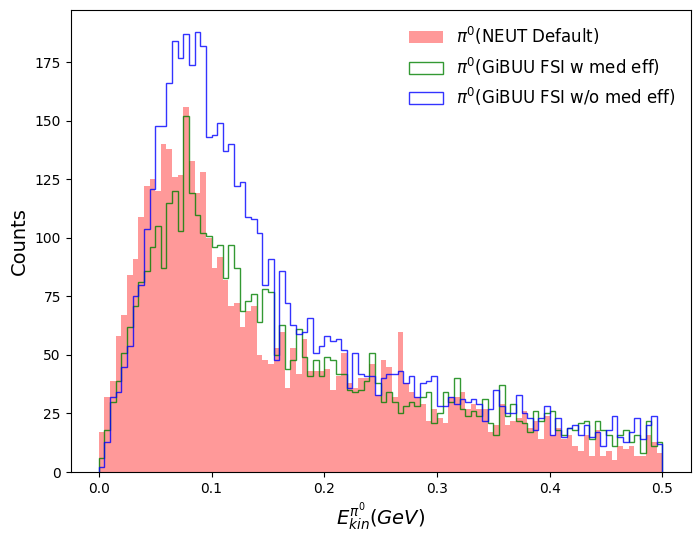

In [62]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot()
ax.hist(Ef[np.logical_and.reduce((pdgf==111,chasef==1))]-0.135,bins=100,color="red",alpha=0.4, label=r"$\pi^0$(NEUT Default)",range=(0,0.5))
# costheta_cutpi_neut=Costhetaf[np.logical_and.reduce((pdgf==111,chasef==1))]

###############################
eg_cutpi_w_med=Ef_gibuu_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==101,chargef_gibuu_w_med==0))]-0.135
# costheta_cutpi_w_med=costheta_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==101,chargef_gibuu_w_med==0))]
eg_cutpi_wo_med=Ef_gibuu_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==101,chargef_gibuu_wo_med==0))]-0.135
# costheta_cutpi_wo_med=costheta_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==101,chargef_gibuu_wo_med==0))]
# costheta_cutn_w_med=costheta_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==0))]
###############################
# ax.hist(eg_cutp[np.logical_and.reduce((eg_cutp>0.00,costheta_cutp>=np.cos(np.pi)))],bins=100,color="red",alpha=0.4,histtype='step',label="p(GiBUU FSI)")
# ax.hist(eg_cutn[np.logical_and.reduce((eg_cutn>0.00,costheta_cutn>=np.cos(np.pi)))],bins=100,color="blue",alpha=0.4,histtype='step', label="n(GiBUU FSI)")
ax.hist(eg_cutpi_w_med[eg_cutpi_w_med>0.00],bins=100,color="green",alpha=0.8,histtype='step',label=r"$\pi^0$(GiBUU FSI w med eff)",range=(0,0.5))
ax.hist(eg_cutpi_wo_med[eg_cutpi_wo_med>0.00],bins=100,color="blue",alpha=0.8,histtype='step',label=r"$\pi^0$(GiBUU FSI w/o med eff)",range=(0,0.5))

# ax.hist(eg_cutn_w_med[np.logical_and.reduce((eg_cutn_w_med>-100.00,costheta_cutn_w_med>=np.cos(np.pi)))],bins=100,color="brown",alpha=0.8,histtype='step', label="n(GiBUU FSI w med eff)",range=(0,0.5))
plt.legend(fontsize=12,framealpha=0.0)
plt.xlabel(r"$E_{kin}^{\pi^0} (GeV)$",fontsize=14)
plt.ylabel(r"Counts",fontsize=14)
# plt.savefig("jg_plots_300725/EkinH_gibuufsi_vs_neut.png")

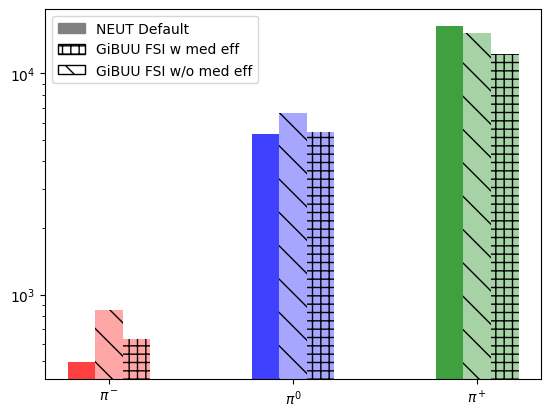

In [63]:
import matplotlib.patches as mpatches

pdg=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.pdg'].array()

chase=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.chase'].array() ## whther the particle is alive or not
pdg_neut=pdg[idx1]
chase_neut=chase[idx1]

bins=[0,1,2,3,4,5,6,7,8,9,10]


number_pi = pdg_neut[(chase_neut == 1) & ((pdg_neut == 111) | (pdg_neut == 211) | (pdg_neut == -211))]
number_gibuu_pi_wo_med=ID_gibuu_wo_med[(ID_gibuu_wo_med!=1) & (ID_gibuu_wo_med!=902) & (ID_gibuu_wo_med!=0)]

# plt.hist([len(i) for i in number_p], bins=bins, label="p NEUT Default",color="red", alpha=0.2)
# plt.hist([len(i) for i in number_pi if len(i)>0], bins=bins, label="NEUT Default",color="pink", alpha=0.4)
# plt.hist([len(i) for i in number_gibuu_pi_wo_med if len(i)>0], bins=bins, label="GiBUU FSI w/o med eff",color="pink",histtype="step", alpha=0.9)

count_pi0,edges_pi0=np.histogram(pdgf[(chasef==1)& (pdgf==111)])
count_pip,edges_pip=np.histogram(pdgf[(chasef==1)& (pdgf==211)])
count_pim,edges_pim=np.histogram(pdgf[(chasef==1)& (pdgf==-211)])

count_pi0_gibuu_wo_med,edges_pi0_gibuu_wo_med=np.histogram(pdgf_gibuu_wo_med[(pdgf_gibuu_wo_med==101) &(chargef_gibuu_wo_med==0)])
count_pip_gibuu_wo_med,edges_pip_gibuu_wo_med=np.histogram(pdgf_gibuu_wo_med[(pdgf_gibuu_wo_med==101) &(chargef_gibuu_wo_med==1)])
count_pim_gibuu_wo_med,edges_pim_gibuu_wo_med=np.histogram(pdgf_gibuu_wo_med[(pdgf_gibuu_wo_med==101) &(chargef_gibuu_wo_med==-1)])



count_pi0_gibuu_w_med,edges_pi0_gibuu_w_med=np.histogram(pdgf_gibuu_w_med[(pdgf_gibuu_w_med==101)&(chargef_gibuu_w_med==0)])
count_pip_gibuu_w_med,edges_pip_gibuu_w_med=np.histogram(pdgf_gibuu_w_med[(pdgf_gibuu_w_med==101)&(chargef_gibuu_w_med==1)])
count_pim_gibuu_w_med,edges_pim_gibuu_w_med=np.histogram(pdgf_gibuu_w_med[(pdgf_gibuu_w_med==101)&(chargef_gibuu_w_med==-1)])


plt.bar(-1.15*np.ones(len(count_pim)),count_pim,width=0.15, color="red", alpha=0.75)
plt.bar(-0.15*np.ones(len(count_pi0)),count_pi0,width=0.15, color="blue", alpha=0.75)
plt.bar(0.85*np.ones(len(count_pip)),count_pip,width=0.15, color="green", alpha=0.75)

plt.bar(-1*np.ones(len(count_pim_gibuu_wo_med)),count_pim_gibuu_wo_med,width=0.15, color="red",hatch="\\", alpha=0.35)
plt.bar(0*np.ones(len(count_pi0_gibuu_wo_med)),count_pi0_gibuu_wo_med,width=0.15, color="blue",hatch="\\", alpha=0.35)
plt.bar(1*np.ones(len(count_pip_gibuu_wo_med)),count_pip_gibuu_wo_med,width=0.15, color="green",hatch="\\", alpha=0.35)


plt.bar(-0.85*np.ones(len(count_pim_gibuu_w_med)),count_pim_gibuu_w_med,width=0.15, color="red",hatch="++", alpha=0.35)
plt.bar(0.15*np.ones(len(count_pi0_gibuu_w_med)),count_pi0_gibuu_w_med,width=0.15, color="blue",hatch="++", alpha=0.35)
plt.bar(1.15*np.ones(len(count_pip_gibuu_w_med)),count_pip_gibuu_w_med,width=0.15, color="green",hatch="++", alpha=0.35)

# plt.legend(fontsize=14)
# plt.yscale("log")
solid = mpatches.Patch(color='gray', label='NEUT Default')  # Solid color
slash = mpatches.Patch(facecolor='white', hatch='\\', edgecolor='black', label='GiBUU FSI w/o med eff')  # '\' hatch
plus = mpatches.Patch(facecolor='white', hatch='++', edgecolor='black', label='GiBUU FSI w med eff')
# Plot your actual bars here (not shown in this code snippet)
plt.yscale("log")
# Add legend
plt.legend(handles=[solid, plus,slash])
plt.xticks(ticks=[-1, 0, 1], labels=[r"$\pi^-$", r"$\pi^0$", r"$\pi^+$"])
plt.savefig("jg_plots_300725/pinumbers_gibuufsi_vs_neut.png")

In [17]:
len(Ef[np.logical_and.reduce((pdgf==211,chasef==1))])

59427

In [18]:
len(eg_cutpi_w_med)

2736

[1.02, 1.19, 1.02, 0.997, 1.2, 1.24, ..., 0.985, 0.982, 0.967, 0.99, 0.983, 1.6] [1, 2, 3, 4, 5, 6, 7, 8, ..., 79994, 79995, 79996, 79997, 79998, 79999, 80000]


<Array [1.19, 1.02, 0.997, 1.2, ..., 1.19, 0.984, 0.98] type='74028 * float64'>

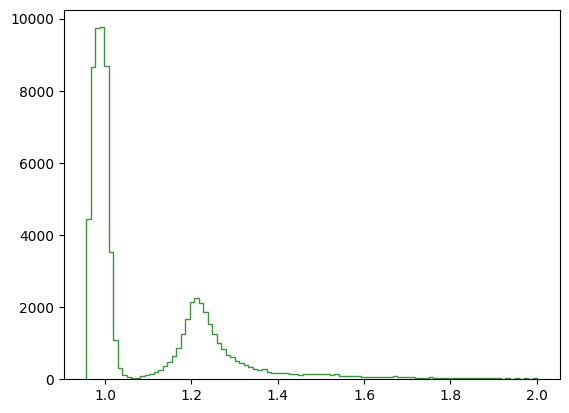

In [64]:
W=file2['NIWGTree']['NIWGEvent/W'].array() ## W
print(W,idx1)
W_neut=W[idx1]
plt.hist(W_neut,bins=100,color="green",alpha=0.8,histtype='step')
W_neut

In [19]:
pdg

<Array [[14, 2212, 13, ..., 211, 2212, 2112], ...] type='100000 * var * int32'>

In [44]:
np.array(px_gibuu_wo_med[:,0])[idx]

array([-0.1556359 , -0.09095287, -0.03873022, ..., -0.04723476,
        0.00308954,  0.117851  ])

(74028, 74028, 74028)

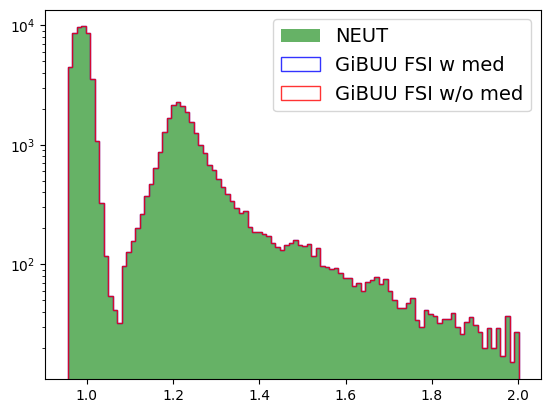

In [65]:
boson_x=0.0-px_gibuu_w_med[:,0][idx2]
boson_y=0.0-py_gibuu_w_med[:,0][idx2]
boson_z=truenuE[idx1]-pz_gibuu_w_med[:,0][idx2]
boson_E=truenuE[idx1]-E_gibuu_w_med[:,0][idx2]


nuc_x=px_gibuu_w_med[:,1][idx2]
nuc_y=py_gibuu_w_med[:,1][idx2]
nuc_z=pz_gibuu_w_med[:,1][idx2]
nuc_E=E_gibuu_w_med[:,1][idx2]

wx=boson_x+nuc_x
wy=boson_y+nuc_y
wz=boson_z+nuc_z
wE=boson_E+nuc_E
w_gibuu_w_med= np.sqrt(wE*wE-wx*wx-wy*wy-wz*wz)
plt.hist(W[idx1],bins=100,color="green",alpha=.60,histtype='bar', label="NEUT")
plt.hist(np.array(w_gibuu_w_med),bins=100,color="blue",alpha=0.8,histtype='step', label="GiBUU FSI w med")


boson_wox=0.0-px_gibuu_wo_med[:,0][idx]
boson_woy=0.0-py_gibuu_wo_med[:,0][idx]
boson_woz=truenuE[idx1]-pz_gibuu_wo_med[:,0][idx]
boson_woE=truenuE[idx1]-E_gibuu_wo_med[:,0][idx]


nuc_wox=px_gibuu_wo_med[:,1][idx]
nuc_woy=py_gibuu_wo_med[:,1][idx]
nuc_woz=pz_gibuu_wo_med[:,1][idx]
nuc_woE=E_gibuu_wo_med[:,1][idx]

wxwo=boson_wox+nuc_wox
wywo=boson_woy+nuc_woy
wzwo=boson_woz+nuc_woz
wEwo=boson_woE+nuc_woE

w_gibuu_wo_med= np.sqrt(wEwo*wEwo-wxwo*wxwo-wywo*wywo-wzwo*wzwo)
plt.hist(np.array(w_gibuu_wo_med),bins=100,color="red",alpha=0.8,histtype='step', label="GiBUU FSI w/o med")

plt.legend(fontsize=14)
plt.yscale("log")
len(w_gibuu_wo_med),len(w_gibuu_w_med),len(W[idx1])

In [ ]:
len(W_neut), 

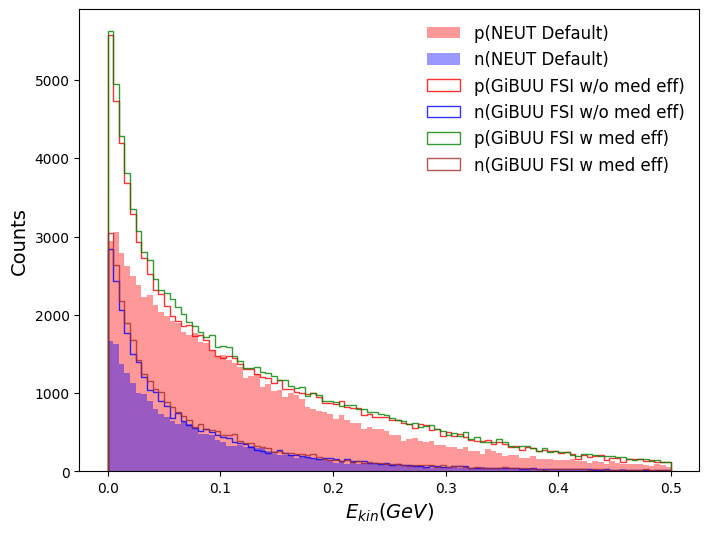

In [66]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot()
ax.hist(Ef[np.logical_and.reduce((pdgf==2212,chasef==1))]-0.935-0.035,bins=100,color="red",alpha=0.4, label="p(NEUT Default)",range=(0.0,0.5))
ax.hist(Ef[np.logical_and.reduce((pdgf==2112,chasef==1))]-0.938-0.035,bins=100,color="blue",alpha=0.4,label="n(NEUT Default)",range=(0.0,0.5))
###############################
# eg_cut_wo_med1=np.sqrt((pxf_gibuu_wo_med**2+pyf_gibuu_wo_med**2+pzf_gibuu_wo_med**2)+0.935**2)-0.935
# eg_cut_wo_med2=np.sqrt((pxf_gibuu_wo_med**2+pyf_gibuu_wo_med**2+pzf_gibuu_wo_med**2)+0.935**2)-0.938

# eg_cutp_wo_med=eg_cut_wo_med1[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==1))]
# eg_cutn_wo_med=eg_cut_wo_med2[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==0))]
eg_cutp_wo_med=Ef_gibuu_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==1))]-0.935
eg_cutn_wo_med=Ef_gibuu_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==0))]-0.938
costheta_cutp_wo_med=costheta_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==1))]
costheta_cutn_wo_med=costheta_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==0))]
###############################
# ax.hist(eg_cutp[np.logical_and.reduce((eg_cutp>0.00,costheta_cutp>=np.cos(np.pi)))],bins=100,color="red",alpha=0.4,histtype='step',label="p(GiBUU FSI)")
# ax.hist(eg_cutn[np.logical_and.reduce((eg_cutn>0.00,costheta_cutn>=np.cos(np.pi)))],bins=100,color="blue",alpha=0.4,histtype='step', label="n(GiBUU FSI)")
# ax.hist(eg_cutp_wo_med[np.logical_and.reduce((eg_cutp_wo_med>0.0,costheta_cutp_wo_med>=np.cos(np.pi)))],bins=100,color="red",alpha=0.8,histtype='step',label="p(GiBUU FSI w/o med eff)",range=(0.0,0.5))
# ax.hist(eg_cutn_wo_med[np.logical_and.reduce((eg_cutn_wo_med>0.0,costheta_cutn_wo_med>=np.cos(np.pi)))],bins=100,color="blue",alpha=0.8,histtype='step', label="n(GiBUU FSI w/o med eff)",range=(0.0,0.5))

eg_cutp_w_med=Ef_gibuu_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==1))]-0.935
eg_cutn_w_med=Ef_gibuu_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==0))]-0.938
costheta_cutp_w_med=costheta_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==1))]
costheta_cutn_w_med=costheta_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==0))]


ax.hist(eg_cutp_wo_med[eg_cutp_wo_med>0.0],bins=100,color="red",alpha=0.8,histtype='step',label="p(GiBUU FSI w/o med eff)",range=(0.0,0.5))
ax.hist(eg_cutn_wo_med[eg_cutn_wo_med>0.0],bins=100,color="blue",alpha=0.8,histtype='step', label="n(GiBUU FSI w/o med eff)",range=(0.0,0.5))


###############################
# eg_cut_w_med1=np.sqrt((pxf_gibuu_w_med**2+pyf_gibuu_w_med**2+pzf_gibuu_w_med**2)+0.935**2)-0.935
# eg_cut_w_med2=np.sqrt((pxf_gibuu_w_med**2+pyf_gibuu_w_med**2+pzf_gibuu_w_med**2)+0.935**2)-0.938

# eg_cutp_w_med=eg_cut_w_med1[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==1))]
# eg_cutn_w_med=eg_cut_w_med2[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==0))]
eg_cutp_w_med=Ef_gibuu_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==1))]-0.935
eg_cutn_w_med=Ef_gibuu_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==0))]-0.938
costheta_cutp_w_med=costheta_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==1))]
costheta_cutn_w_med=costheta_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==0))]
###############################
# ax.hist(eg_cutp[np.logical_and.reduce((eg_cutp>0.00,costheta_cutp>=np.cos(np.pi)))],bins=100,color="red",alpha=0.4,histtype='step',label="p(GiBUU FSI)")
# ax.hist(eg_cutn[np.logical_and.reduce((eg_cutn>0.00,costheta_cutn>=np.cos(np.pi)))],bins=100,color="blue",alpha=0.4,histtype='step', label="n(GiBUU FSI)")
ax.hist(eg_cutp_w_med[eg_cutp_w_med>0.0],bins=100,color="green",alpha=0.8,histtype='step',label="p(GiBUU FSI w med eff)",range=(0.0,0.5))
ax.hist(eg_cutn_w_med[eg_cutn_w_med>0.0],bins=100,color="brown",alpha=0.8,histtype='step', label="n(GiBUU FSI w med eff)",range=(0.0,0.5))


# ax.hist(eg_cutp_w_med[np.logical_and.reduce((eg_cutp_w_med>0.0,costheta_cutp_w_med>=np.cos(np.pi)))],bins=100,color="green",alpha=0.8,histtype='step',label="p(GiBUU FSI w med eff)",range=(0.0,0.5))
# ax.hist(eg_cutn_w_med[np.logical_and.reduce((eg_cutn_w_med>0.0,costheta_cutn_w_med>=np.cos(np.pi)))],bins=100,color="brown",alpha=0.8,histtype='step', label="n(GiBUU FSI w med eff)",range=(0.0,0.5))
plt.legend(fontsize=12,framealpha=0.0)
plt.xlabel(r"$E_{kin} (GeV)$",fontsize=14)
plt.ylabel(r"Counts",fontsize=14)
plt.savefig("jg_plots_300725/EkinH_gibuufsi_vs_neut.png")

Text(0, 0.5, 'Counts')

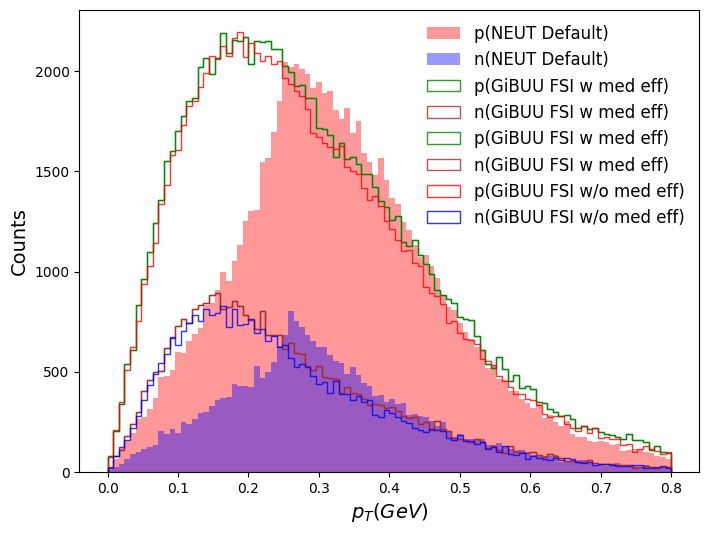

In [67]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot()
ax.hist(Ptf[np.logical_and.reduce((pdgf==2212,chasef==1,Ef-0.935-0.035>0))],bins=100, color="red",alpha=0.4,label="p(NEUT Default)",range=(0,0.8))
ax.hist(Ptf[np.logical_and.reduce((pdgf==2112,chasef==1,Ef-0.938-0.035>0))],bins=100,color="blue",alpha=0.4,label="n(NEUT Default)",range=(0,0.8))
###############################
# Ptg_cutp_wo_med=ptf_gibuu_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==1,Ef_gibuu_wo_med-0.935>0))]
# Ptg_cutn_wo_med=ptf_gibuu_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==0,Ef_gibuu_wo_med-0.938>0))]
# costheta_cutp_wo_med=costheta_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==1))]
# costheta_cutn_wo_med=costheta_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==0))]
# ###############################
# ax.hist(Ptg_cutp_wo_med[np.logical_and.reduce((eg_cutp_wo_med>0.00,costheta_cutp_wo_med>=np.cos(np.pi)))],bins=100,color="red",alpha=0.8,histtype='step',label="p(GiBUU FSI w/o med eff)",range=(0,0.8))
# ax.hist(Ptg_cutn_wo_med[np.logical_and.reduce((eg_cutn_wo_med>0.00,costheta_cutn_wo_med>=np.cos(np.pi)))],bins=100,color="blue",alpha=0.8,histtype='step',label="n(GiBUU FSI w/o med eff)",range=(0,0.8))


###############################
Ptg_cutp_w_med=ptf_gibuu_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==1))]
Ptg_cutn_w_med=ptf_gibuu_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==0))]
costheta_cutp_w_med=costheta_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==1))]
costheta_cutn_w_med=costheta_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==0))]
###############################
ax.hist(Ptg_cutp_w_med[np.logical_and.reduce((eg_cutp_w_med>0.00,costheta_cutp_w_med>=np.cos(np.pi)))],bins=100,color="green",alpha=0.8,histtype='step',label="p(GiBUU FSI w med eff)",range=(0,0.8))
ax.hist(Ptg_cutn_w_med[np.logical_and.reduce((eg_cutn_w_med>0.00,costheta_cutn_w_med>=np.cos(np.pi)))],bins=100,color="brown",alpha=0.8,histtype='step',label="n(GiBUU FSI w med eff)",range=(0,0.8))




###############################
Ptg_cutp_wo_med=ptf_gibuu_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==1))]
Ptg_cutn_wo_med=ptf_gibuu_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==0))]
costheta_cutp_wo_med=costheta_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==1))]
costheta_cutn_wo_med=costheta_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==0))]
###############################
ax.hist(Ptg_cutp_w_med[np.logical_and.reduce((eg_cutp_w_med>0.00,costheta_cutp_w_med>=np.cos(np.pi)))],bins=100,color="green",alpha=0.8,histtype='step',label="p(GiBUU FSI w med eff)",range=(0,0.8))
ax.hist(Ptg_cutn_w_med[np.logical_and.reduce((eg_cutn_w_med>0.00,costheta_cutn_w_med>=np.cos(np.pi)))],bins=100,color="brown",alpha=0.8,histtype='step',label="n(GiBUU FSI w med eff)",range=(0,0.8))


ax.hist(Ptg_cutp_wo_med[np.logical_and.reduce((eg_cutp_wo_med>0.00,costheta_cutp_wo_med>=np.cos(np.pi)))],bins=100,color="red",alpha=0.8,histtype='step',label="p(GiBUU FSI w/o med eff)",range=(0,0.8))
ax.hist(Ptg_cutn_wo_med[np.logical_and.reduce((eg_cutn_wo_med>0.00,costheta_cutn_wo_med>=np.cos(np.pi)))],bins=100,color="blue",alpha=0.8,histtype='step',label="n(GiBUU FSI w/o med eff)",range=(0,0.8))

plt.legend(fontsize=12,framealpha=0.0)
plt.xlabel(r"$p_{T}(GeV)$",fontsize=14)
plt.ylabel(r"Counts",fontsize=14)
# plt.savefig("jg_plots_300725/pTH_gibuufsi_vs_neut.png")

Text(0, 0.5, 'Counts')

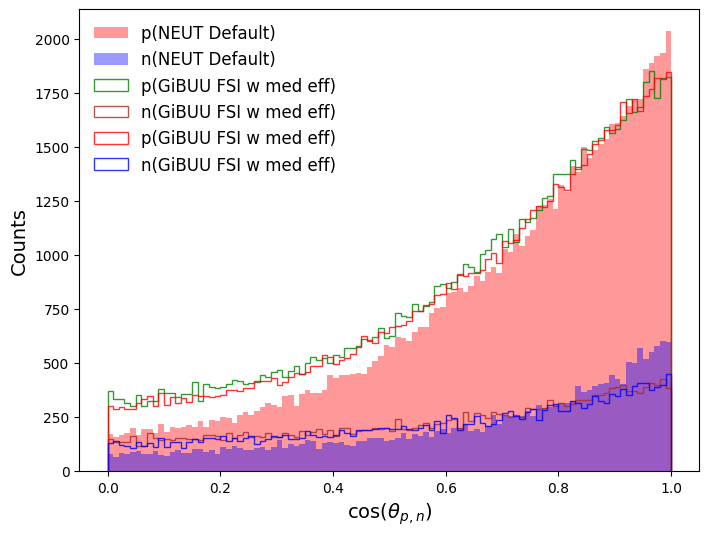

In [68]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot()
Costhetaf=Pzf/np.sqrt(Pxf**2+Pyf**2+Pzf**2)
ax.hist(Costhetaf[np.logical_and.reduce((pdgf==2212,chasef==1,Ef-0.935-0.035>0))],bins=100, color="red",alpha=0.4,label="p(NEUT Default)",range=(0,1))
ax.hist(Costhetaf[np.logical_and.reduce((pdgf==2112,chasef==1,Ef-0.938-0.035>0))],bins=100, color="blue",alpha=0.4,label="n(NEUT Default)",range=(0,1))

# ax.hist(Ptf[np.logical_and.reduce((pdgf==2212,chasef==1,Ef-0.935-0.035>0))],bins=100, color="red",alpha=0.4,label="p(NEUT Default)",range=(0,0.8))
# ax.hist(Ptf[np.logical_and.reduce((pdgf==2112,chasef==1,Ef-0.938-0.035>0))],bins=100,color="blue",alpha=0.4,label="n(NEUT Default)",range=(0,0.8))
# ###############################
# Ptg_cutp_wo_med=ptf_gibuu_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==1,Ef_gibuu_wo_med-0.935>0))]
# Ptg_cutn_wo_med=ptf_gibuu_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==0,Ef_gibuu_wo_med-0.938>0))]
# costheta_cutp_wo_med=costheta_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==1))]
# costheta_cutn_wo_med=costheta_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==0))]
# ###############################
# ax.hist(costheta_cutp_wo_med[np.logical_and.reduce((eg_cutp_wo_med>0.00,costheta_cutp_wo_med>=np.cos(np.pi)))],bins=100,color="red",alpha=0.8,histtype='step',label="p(GiBUU FSI w/o med eff)",range=(0,1))
# ax.hist(costheta_cutn_wo_med[np.logical_and.reduce((eg_cutn_wo_med>0.00,costheta_cutn_wo_med>=np.cos(np.pi)))],bins=100,color="blue",alpha=0.8,histtype='step',label="n(GiBUU FSI w/o med eff)",range=(0,1))


###############################
Ptg_cutp_wo_med=ptf_gibuu_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==1))]
Ptg_cutn_wo_med=ptf_gibuu_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==0))]
costheta_cutp_wo_med=costheta_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==1))]
costheta_cutn_wo_med=costheta_wo_med[np.logical_and.reduce((pdgf_gibuu_wo_med==1,chargef_gibuu_wo_med==0))]
###############################

Ptg_cutp_w_med=ptf_gibuu_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==1))]
Ptg_cutn_w_med=ptf_gibuu_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==0))]
costheta_cutp_w_med=costheta_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==1))]
costheta_cutn_w_med=costheta_w_med[np.logical_and.reduce((pdgf_gibuu_w_med==1,chargef_gibuu_w_med==0))]
###############################


ax.hist(costheta_cutp_w_med[np.logical_and.reduce((eg_cutp_w_med>0.00,costheta_cutp_w_med>=np.cos(np.pi)))],bins=100,color="green",alpha=0.8,histtype='step',label="p(GiBUU FSI w med eff)",range=(0,1))
ax.hist(costheta_cutn_w_med[np.logical_and.reduce((eg_cutn_w_med>0.00,costheta_cutn_w_med>=np.cos(np.pi)))],bins=100,color="brown",alpha=0.8,histtype='step',label="n(GiBUU FSI w med eff)",range=(0,1))


ax.hist(costheta_cutp_wo_med[np.logical_and.reduce((eg_cutp_wo_med>0.00,costheta_cutp_wo_med>=np.cos(np.pi)))],bins=100,color="red",alpha=0.8,histtype='step',label="p(GiBUU FSI w med eff)",range=(0,1))
ax.hist(costheta_cutn_wo_med[np.logical_and.reduce((eg_cutn_wo_med>0.00,costheta_cutn_wo_med>=np.cos(np.pi)))],bins=100,color="blue",alpha=0.8,histtype='step',label="n(GiBUU FSI w med eff)",range=(0,1))

plt.legend(fontsize=12,framealpha=0.0)
plt.xlabel(r"$\cos(\theta_{p,n})$",fontsize=14)
plt.ylabel(r"Counts",fontsize=14)
# plt.savefig("jg_plots_300725/pTH_gibuufsi_vs_neut.png")

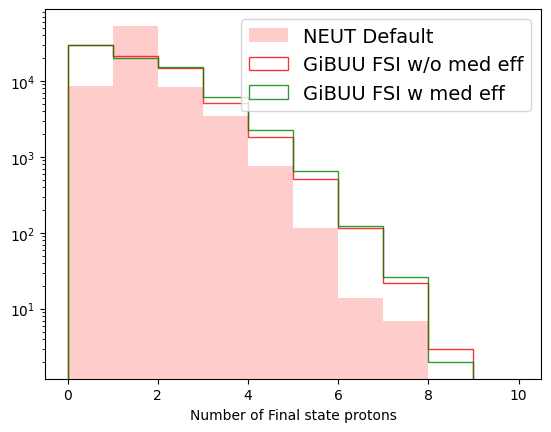

In [69]:
pdg=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.pdg'].array()
E=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.p'].array()[:]['fE']
chase=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.chase'].array() ## whther the particle is alive or not
pdg_neut=pdg[idx1]
chase_neut=chase[idx1]
E_neut=E[idx1]



bins=[0,1,2,3,4,5,6,7,8,9,10]


number_p=pdg_neut[(chase_neut == 1) & (pdg_neut == 2212) & (E_neut-0.935-0.035>0)]
number_n=pdg_neut[(chase_neut == 1) & (pdg_neut == 2112)& (E_neut-0.938-0.035>0)]

plt.hist([len(i) for i in number_p], bins=bins, label="NEUT Default",color="red", alpha=0.2)

number_gibuu_p_wo_med=ID_gibuu_wo_med[idx][(ID_gibuu_wo_med[idx]==1) & (charge_gibuu_wo_med[idx]==1) & (E_gibuu_wo_med[idx]-0.935>0) & (history_gibuu_wo_med[idx]!=0 )]
number_gibuu_p_w_med=ID_gibuu_w_med[idx2][(ID_gibuu_w_med[idx2]==1) & (charge_gibuu_w_med[idx2]==1) & (E_gibuu_w_med[idx2]-0.935>0) & (history_gibuu_w_med[idx2]!=0 )]


plt.hist([len(i) for i in number_gibuu_p_wo_med], bins=bins, label="GiBUU FSI w/o med eff", histtype="step",color="red", alpha=0.8)


plt.hist([len(i) for i in number_gibuu_p_w_med], bins=bins, label="GiBUU FSI w med eff", histtype="step",color="green", alpha=0.8)


plt.xlabel("Number of Final state protons")
plt.yscale("log")
plt.legend(fontsize=14)
plt.savefig("pnumbers_gibuufsi_vs_neut.png")

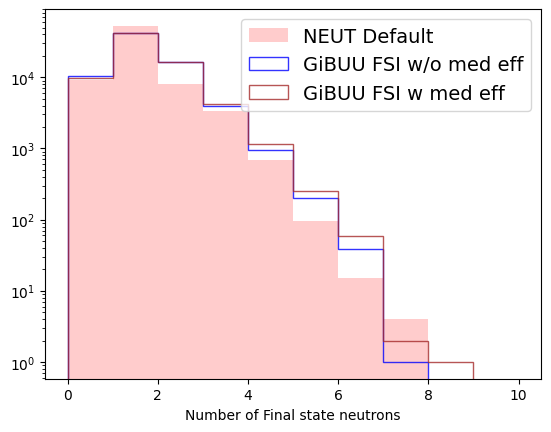

In [70]:
pdg=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.pdg'].array()
E=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.p'].array()[:]['fE']
chase=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.chase'].array() ## whther the particle is alive or not
pdg_neut=pdg[idx1]
chase_neut=chase[idx1]
E_neut=E[idx1]
bins=[0,1,2,3,4,5,6,7,8,9,10]


number_p=pdg_neut[(chase_neut == 1) & (pdg_neut == 2212) & (E_neut-0.938-0.035>0)]
number_n=pdg_neut[(chase_neut == 1) & (pdg_neut == 2112)& (E_neut-0.938-0.035>0)]

plt.hist([len(i) for i in number_p], bins=bins, label="NEUT Default",color="red", alpha=0.2)
#plt.hist([len(i) for i in number_n], bins=10, label="n NEUT Default",color="blue", alpha=0.4)


number_gibuu_n_wo_med=ID_gibuu_wo_med[idx][(ID_gibuu_wo_med[idx]==1) & (charge_gibuu_wo_med[idx]==0)& (E_gibuu_wo_med[idx]-0.935>0)]
number_gibuu_n_w_med=ID_gibuu_w_med[idx2][(ID_gibuu_w_med[idx2]==1) & (charge_gibuu_w_med[idx2]==0) & (E_gibuu_w_med[idx2]-0.935>0)]


plt.hist([len(i) for i in number_gibuu_n_wo_med], bins=bins, label="GiBUU FSI w/o med eff", histtype="step",color="blue", alpha=0.8)


plt.hist([len(i) for i in number_gibuu_n_w_med], bins=bins, label="GiBUU FSI w med eff", histtype="step",color="brown", alpha=0.8)


plt.xlabel("Number of Final state neutrons")
plt.yscale("log")
plt.legend(fontsize=14)
plt.savefig("nnumbers_gibuufsi_vs_neut.png")

In [17]:
charge_gibuu_w_med

<Array [[-1, 1, 1, 1, 1, 0], ..., [-1, 1, ..., 1]] type='91400 * var * int64'>

In [27]:
ID_gibuu_w_med

<Array [[902, 1, 1, 1, 1, 1], ..., [902, 1, ..., 1]] type='16240 * var * int64'>

In [4]:
pdgf_gibuu_w_med

<Array [1, 1, 1, 1, 1, 1, 1, ..., 101, 1, 101, 1, 101, 1] type='50489 * int64'>

In [6]:
ID_gibuu_w_med

<Array [[902, 1, 1, 1, 1, 1], ..., [902, 1, ..., 1]] type='16240 * var * int64'>

Text(0, 0.5, 'Counts')

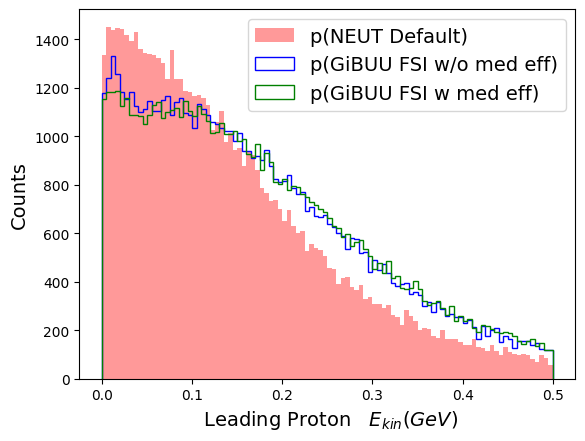

In [72]:

pdg=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.pdg'].array()
E=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.p'].array()[:]['fE']
chase=file2['NIWGTree'][ 'NIWGEvent/part_stack/part_stack.chase'].array() ## whther the particle is alive or not
pdg_neut=pdg[idx1]
chase_neut=chase[idx1]
E_neut=E[idx1]
len(E_neut),len(chase_neut),len(pdg_neut)
neut_ekin_lead=[np.max(i)-0.935-0.035 for i in E_neut[(pdg_neut==2212) & (chase_neut==1)] if len(i) > 0]
gibuu_ekin_lead_wo_med=[np.max(i)-0.935 for i in E_gibuu_wo_med[idx][:,2:][(ID_gibuu_wo_med[idx][:,2:]==1) & (charge_gibuu_wo_med[idx][:,2:]==1)] if len(i) > 0]
gibuu_ekin_lead_w_med=[np.max(i)-0.935 for i in E_gibuu_w_med[idx2][:,2:][(ID_gibuu_w_med[idx2][:,2:]==1) & (charge_gibuu_w_med[idx2][:,2:]==1)] if len(i) > 0]

neut_ekin_lead=np.array(neut_ekin_lead)
gibuu_ekin_lead_wo_med=np.array(gibuu_ekin_lead_wo_med)
gibuu_ekin_lead_w_med=np.array(gibuu_ekin_lead_w_med)
# counts1,edges1=np.histogram(neut_ekin_lead, bins=100, range=(0,0.5))
# counts2,edges2=np.histogram([np.max(i) for i in Ef_gibuu_wo_med[(ID_gibuu_wo_med==1) & (charge_gibuu_wo_med==1)] if len(i) > 0], bins=(0,0.5,0.01),range=(0,0.5))
# plt.step(edges1[:-1], counts1, where="post",label="p(NEUT Default)",color='red',alpha=0.4)
# plt.fill_between(edges1[:-1], counts1, step="post",color='red',alpha=0.4)
# plt.step(edges2[:-1], counts2, where="post",label="p(GiBUU FSI w/o med eff)",color="blue")
# plt.step(edges3[:-1], counts3, where="post",label="p(GiBUU FSI w med eff)",color="green")
plt.hist(neut_ekin_lead[neut_ekin_lead>0], bins=100,label="p(NEUT Default)",color='red',alpha=0.4, range=(0,0.5))
plt.hist(gibuu_ekin_lead_wo_med[gibuu_ekin_lead_wo_med>0], bins=100,label="p(GiBUU FSI w/o med eff)",color="blue",histtype='step',range=(0,0.5))
plt.hist(gibuu_ekin_lead_w_med[gibuu_ekin_lead_w_med>0], bins=100,label="p(GiBUU FSI w med eff)",color='green',histtype='step',range=(0,0.5))

plt.legend(fontsize=14)
plt.xlabel(r" Leading Proton   $E_{kin} (GeV)$",fontsize=14)
plt.ylabel(r"Counts",fontsize=14)
# print(len(E_neut),len(Efl_gibuu_wo_med),len(Efl_gibuu_w_med),len(gibuu_ekin_lead_wo_med),len(gibuu_ekin_lead_w_med),len(neut_ekin_lead))


In [68]:
E_gibuu_wo_med

<Array [[0.2, 0.94, 0.181, 1.31], ..., [...]] type='47752 * var * float64'>

In [71]:
E_gibuu_wo_med[idx][:,2:]

<Array [[0.181, 1.31], [1.38], ..., [0.946, 1.09]] type='46239 * var * float64'>

In [25]:
len(neut_ekin_lead[neut_ekin_lead>0]),len(gibuu_ekin_lead_w_med[gibuu_ekin_lead_w_med>0])

(38725, 41709)

38725
[True]
38725
[True]


In [73]:

##########################################################
px_neut=px[idx1]
py_neut=py[idx1]
pz_neut=pz[idx1]

Ef_neut=E[idx1]-0.935-0.035
chase_neut=chase[idx1]
pdg_neut=pdg[idx1]

dptx_neut=px_neut+px_neut[:,2]
dpty_neut=py_neut+py_neut[:,2]
len(px),len(dptx_neut)
leading_proton_index_neut=[int(np.argmax(i)) for i in Ef_neut[(pdg_neut==2212) & (chase_neut==1) & (Ef_neut>0)] if len(i) > 0]
print(len(leading_proton_index_neut))

len(leading_proton_index_neut)
masked_dptx = dptx_neut[(pdg_neut == 2212) & (chase_neut == 1)& (Ef_neut>0)]
masked_dpty = dpty_neut[(pdg_neut == 2212) & (chase_neut == 1)& (Ef_neut>0)]

# # # Filter out empty sublists (length > 0)
dptx_neut = masked_dptx[ak.num(masked_dptx, axis=1) > 0]
dpty_neut= masked_dpty[ak.num(masked_dpty, axis=1) > 0]
same_shape = ak.num(dptx_neut, axis=1) == ak.num(dpty_neut, axis=1)
print(np.unique(same_shape))
print(len(dptx_neut))
dptx_mod_neut=[]
dpty_mod_neut=[]
counter = 0
for i in leading_proton_index_neut:
    if len(dptx_neut[counter]) > 0 and len(dpty_neut[counter]) > 0:
        #print(i,dptx[counter][i])
        dptx_mod_neut.append(dptx_neut[counter][i])
        dpty_mod_neut.append(dpty_neut[counter][i])

    counter += 1
dptx_mod_neut=ak.Array(dptx_mod_neut)
dpty_mod_neut=ak.Array(dpty_mod_neut)    
dptf_neut=np.sqrt(dptx_mod_neut**2+dpty_mod_neut**2)
# ########################## with medium eff###############
# ################## delta pt for GiBUU###############################
dptx_w_med=px_gibuu_w_med+px_gibuu_w_med[:,0]
dpty_w_med=py_gibuu_w_med+py_gibuu_w_med[:,0]
# Efn_gibuu_w_med=np.sqrt((px_gibuu_w_med**2+py_gibuu_w_med**2+pz_gibuu_w_med**2)+0.935**2)-0.935
Efn_gibuu_w_med=E_gibuu_w_med-0.935

##Efn_gibuu_w_med=np.sqrt(px_gibuu_mod_w_med**2+py_gibuu_mod_w_med**2+pz_gibuu_mod_w_med**2+0.938**2)-0.938
# # # # # print([len(i) for i in px_list])
# # # # # print(invalid_index)
# # # print(min(len_Efn_gibuu))
leading_proton_index_gibuu_w_med=[int(np.argmax(i)) for i in Efn_gibuu_w_med[idx2][:,2:][(ID_gibuu_w_med[idx2][:,2:]==1) & (charge_gibuu_w_med[idx2][:,2:]==1)&(Efn_gibuu_w_med[idx2][:,2:]>0)] if len(i) > 0]
# # leading_proton_index_gibuu,Efn_gibuu[(ID_gibuu_mod==1) & (charge_gibuu_mod==1)]
dptx_w_med=ak.Array([i for i in dptx_w_med[idx2][:,2:][(ID_gibuu_w_med[idx2][:,2:]==1) & (charge_gibuu_w_med[idx2][:,2:]==1)&(Efn_gibuu_w_med[idx2][:,2:]>0)] if len(i) > 0])
dpty_w_med=ak.Array([i for i  in dpty_w_med[idx2][:,2:][(ID_gibuu_w_med[idx2][:,2:]==1) & (charge_gibuu_w_med[idx2][:,2:]==1)&(Efn_gibuu_w_med[idx2][:,2:]>0)] if len(i) > 0])
# # len(dptx),len(Efn_gibuu[(ID_gibuu_mod==1) & (charge_gibuu_mod==1)])
# # dptx,Efn_gibuu[(ID_gibuu_mod==1) & (charge_gibuu_mod==1)]
#len_E_gibuu=[len(i) for i in Efn_gibuu[(ID_gibuu_mod==1) & (charge_gibuu_mod==1)]if len(i) > 0]    
same_shape = ak.num(dptx_w_med, axis=1) == ak.num(dpty_w_med, axis=1)
print(np.unique(same_shape))
# print(min(len_E_gibuu))
dptx_mod_w_med=[]
dpty_mod_w_med=[]
counter = 0
for i in leading_proton_index_gibuu_w_med:
    if len(dptx_w_med[counter]) > 0 and len(dpty_w_med[counter]) > 0:
        dptx_mod_w_med.append(dptx_w_med[counter][i])
        dpty_mod_w_med.append(dpty_w_med[counter][i])

    counter += 1
# # leading_proton_index_gibuu , len(leading_proton_index_gibuu)    
# Efn_gibuu[(ID_gibuu_mod[i]==1) & (charge_gibuu_mod[i]==1)]
dptx_mod_w_med=ak.Array(dptx_mod_w_med)
dpty_mod_w_med=ak.Array(dpty_mod_w_med)
dptf_gibuu_w_med=np.sqrt(dptx_mod_w_med**2+dpty_mod_w_med**2)


# ########################################################
dptx_wo_med=px_gibuu_wo_med+px_gibuu_wo_med[:,0]
dpty_wo_med=py_gibuu_wo_med+py_gibuu_wo_med[:,0]
# Efn_gibuu_wo_med=np.sqrt((px_gibuu_wo_med**2+py_gibuu_wo_med**2+pz_gibuu_wo_med**2)+0.935**2)-0.935
Efn_gibuu_wo_med=E_gibuu_wo_med-0.935

##Efn_gibuu_w_med=np.sqrt(px_gibuu_mod_w_med**2+py_gibuu_mod_w_med**2+pz_gibuu_mod_w_med**2+0.938**2)-0.938
# # # # # print([len(i) for i in px_list])
# # # # # print(invalid_index)
# # # print(min(len_Efn_gibuu))
leading_proton_index_gibuu_wo_med=[int(np.argmax(i)) for i in Efn_gibuu_wo_med[idx][:,2:][(ID_gibuu_wo_med[idx][:,2:]==1) & (charge_gibuu_wo_med[idx][:,2:]==1)&(Efn_gibuu_wo_med[idx][:,2:]>0)] if len(i) > 0]
# # leading_proton_index_gibuu,Efn_gibuu[(ID_gibuu_mod==1) & (charge_gibuu_mod==1)]
dptx_wo_med=ak.Array([i for i in dptx_wo_med[idx][:,2:][(ID_gibuu_wo_med[idx][:,2:]==1) & (charge_gibuu_wo_med[idx][:,2:]==1)&(Efn_gibuu_wo_med[idx][:,2:]>0) ] if len(i) > 0])
dpty_wo_med=ak.Array([i for i  in dpty_wo_med[idx][:,2:][(ID_gibuu_wo_med[idx][:,2:]==1) & (charge_gibuu_wo_med[idx][:,2:]==1)&(Efn_gibuu_wo_med[idx][:,2:]>0)] if len(i) > 0])
# # len(dptx),len(Efn_gibuu[(ID_gibuu_mod==1) & (charge_gibuu_mod==1)])
# # dptx,Efn_gibuu[(ID_gibuu_mod==1) & (charge_gibuu_mod==1)]
#len_E_gibuu=[len(i) for i in Efn_gibuu[(ID_gibuu_mod==1) & (charge_gibuu_mod==1)]if len(i) > 0]    
same_shape = ak.num(dptx_wo_med, axis=1) == ak.num(dpty_wo_med, axis=1)
print(np.unique(same_shape))
# print(min(len_E_gibuu))
dptx_mod_wo_med=[]
dpty_mod_wo_med=[]
counter = 0
for i in leading_proton_index_gibuu_wo_med:
    if len(dptx_wo_med[counter]) > 0 and len(dpty_wo_med[counter]) > 0:
        dptx_mod_wo_med.append(dptx_wo_med[counter][i])
        dpty_mod_wo_med.append(dpty_wo_med[counter][i])

    counter += 1
# # leading_proton_index_gibuu , len(leading_proton_index_gibuu)    
# Efn_gibuu[(ID_gibuu_mod[i]==1) & (charge_gibuu_mod[i]==1)]
dptx_mod_wo_med=ak.Array(dptx_mod_wo_med)
dpty_mod_wo_med=ak.Array(dpty_mod_wo_med)
dptf_gibuu_wo_med=np.sqrt(dptx_mod_wo_med**2+dpty_mod_wo_med**2)


65552
[True]
65552
[True]
[True]


40901 44296 44437


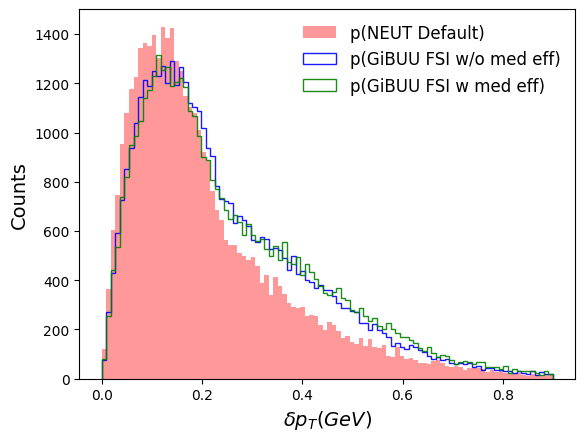

In [74]:
plt.hist(dptf_neut,color="red",bins=100,alpha=0.4,label="p(NEUT Default)",range=(0,0.9))
plt.hist(dptf_gibuu_wo_med,color="blue",bins=100,alpha=0.9,histtype='step',label="p(GiBUU FSI w/o med eff)",range=(0,0.9))
plt.hist(dptf_gibuu_w_med,color="green",bins=100,alpha=0.9,histtype='step',label="p(GiBUU FSI w med eff)",range=(0,0.9))

plt.legend(fontsize=12,framealpha=0.0)
plt.xlabel(r"$\delta p_T(GeV)$",fontsize=14)
plt.ylabel(r"Counts",fontsize=14)
print(len(dptf_neut),len(dptf_gibuu_wo_med),len(dptf_gibuu_w_med))

/home/t2k/pingaldg/.local/lib/python3.9/site-packages/awkward/_nplikes/array_module.py:251: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


65552
[True]
65552
[True]
[True]


Text(0, 0.5, 'Counts')

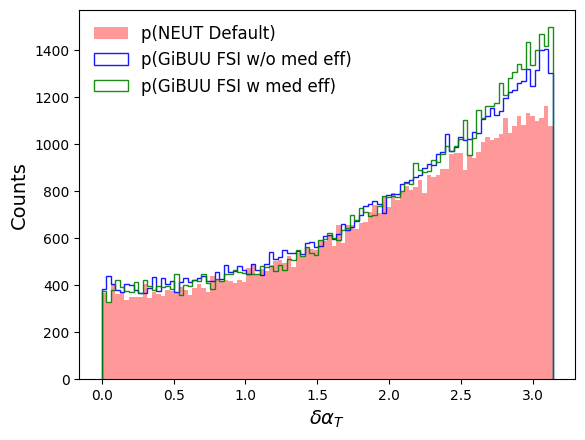

In [74]:
##########################################################
px_neut=px[idx1]
py_neut=py[idx1]
pz_neut=pz[idx1]

# Ef_neut=np.sqrt((px_neut**2+py_neut**2+pz_neut**2)+0.935**2)-0.935-0.035
chasef_neut=chase[idx1]
pdg_neut=pdg[idx1]
# Ptfl_gibuu_wo_med=np.sqrt(Pxfl_gibuu_wo_med**2+Pyfl_gibuu_wo_med**2)
Pt_gibuu_w_med=np.sqrt(px_gibuu_w_med**2+py_gibuu_w_med**2)
Pt_gibuu_wo_med=np.sqrt(px_gibuu_wo_med**2+py_gibuu_wo_med**2)

# ################## delta pt for GiBUU###############################

# dptx_wo_med=Pxfl_gibuu_wo_med+Pxfl_gibuu_wo_med[:,0]
# dpty_wo_med=Pyfl_gibuu_wo_med+Pyfl_gibuu_wo_med[:,0]
# Efn_gibuu_wo_med=Efl_gibuu_wo_med-0.935
# dalpha_wo_med=(-Pxfl_gibuu_wo_med*dptx_wo_med-Pyfl_gibuu_wo_med*dpty_wo_med)/((Ptfl_gibuu_wo_med)*(np.sqrt(dptx_wo_med*dptx_wo_med+dpty_wo_med*dpty_wo_med)))

# # # # # # print([len(i) for i in px_list])
# # # # # # print(invalid_index)
# # # # print(min(len_Efn_gibuu))
# leading_proton_index_gibuu_wo_med=[int(np.argmax(i)) for i in Efl_gibuu_wo_med[(IDfl_gibuu_wo_med==1) & (chargefl_gibuu_wo_med==1) & (Efl_gibuu_wo_med>0)] if len(i) > 0]
# dalpha_wo_med=ak.Array([i for i in dalpha_wo_med[(IDfl_gibuu_wo_med==1) & (chargefl_gibuu_wo_med==1)& (Efl_gibuu_wo_med>0)] if len(i) > 0])

# # # leading_proton_index_gibuu,Efn_gibuu[(ID_gibuu_mod==1) & (charge_gibuu_mod==1)]
# # dptx_wo_med=ak.Array([i for i in dptx_wo_med[(IDfl_gibuu_wo_med==1) & (chargefl_gibuu_wo_med==1) & (Efl_gibuu_wo_med>0)] if len(i) > 0])
# # dpty_wo_med=ak.Array([i for i  in dpty_wo_med[(IDfl_gibuu_wo_med==1) & (chargefl_gibuu_wo_med==1)& (Efl_gibuu_wo_med>0)] if len(i) > 0])
# # # # len(dptx),len(Efn_gibuu[(ID_gibuu_mod==1) & (charge_gibuu_mod==1)])
# # # # dptx,Efn_gibuu[(ID_gibuu_mod==1) & (charge_gibuu_mod==1)]
# # # len_E_gibuu=[len(i) for i in Efn_gibuu[(ID_gibuu_mod==1) & (charge_gibuu_mod==1)]if len(i) > 0]    
# same_shape = ak.num(dptx_wo_med, axis=1) == ak.num(dpty_wo_med, axis=1)
# print(np.unique(same_shape))

# dalpha_mod_wo_med=[]
# counter = 0
# for i in leading_proton_index_gibuu_wo_med:
#     if len(dalpha_wo_med[counter]) > 0 :
#         #print(i,dptx[counter][i])
#         dalpha_mod_wo_med.append(dalpha_wo_med[counter][i])

#     counter += 1
# # # leading_proton_index_gibuu , len(leading_proton_index_gibuu)    
# # Efn_gibuu[(ID_gibuu_mod[i]==1) & (charge_gibuu_mod[i]==1)]
# dalpha_mod_wo_med=ak.Array(dalpha_mod_wo_med)
# dalphaf_gibuu_wo_med=dalpha_mod_wo_med

# ################## delta pt for NEUT###############################

# ##########################################################
px_neut=px[idx1]
py_neut=py[idx1]
Ef_neut=E[idx1]-0.935-0.035
chase_neut=chase[idx1]
pdg_neut=pdg[idx1]
pt_neut=np.sqrt(px_neut**2+py_neut**2)
dptx_neut=px_neut+px_neut[:,2]
dpty_neut=py_neut+py_neut[:,2]
dalpha_neut=(-px_neut*dptx_neut-py_neut*dpty_neut)/((pt_neut)*(np.sqrt(dptx_neut*dptx_neut+dpty_neut*dpty_neut)))

len(px),len(dptx_neut)
leading_proton_index_neut=[int(np.argmax(i)) for i in Ef_neut[(pdg_neut==2212) & (chase_neut==1) & (Ef_neut>0)] if len(i) > 0]
print(len(leading_proton_index_neut))


##########################################################

len(leading_proton_index_neut)
masked_dalpha = dalpha_neut[(pdg_neut == 2212) & (chase_neut == 1)& (Ef_neut>0)]

# # Filter out empty sublists (length > 0)
dalpha_neut = masked_dalpha[ak.num(masked_dalpha, axis=1) > 0]
same_shape = ak.num(dalpha_neut, axis=1) == ak.num(dalpha_neut, axis=1)
print(np.unique(same_shape))
print(len(dalpha_neut))
dalpha_mod_neut=[]
counter = 0
for i in leading_proton_index_neut:
    if len(dalpha_neut[counter]) > 0 :
        #print(i,dptx[counter][i])
        dalpha_mod_neut.append(dalpha_neut[counter][i])

    counter += 1
dalpha_mod_neut=ak.Array(dalpha_mod_neut)
dalphaf_neut=dalpha_mod_neut

# # ########################## with medium eff###############
# # ################## delta pt for GiBUU###############################
dptx_w_med=px_gibuu_w_med+px_gibuu_w_med[:,0]
dpty_w_med=py_gibuu_w_med+py_gibuu_w_med[:,0]
Efn_gibuu_w_med=E_gibuu_w_med-0.935
dalpha_w_med=(-px_gibuu_w_med*dptx_w_med-py_gibuu_w_med*dpty_w_med)/((Pt_gibuu_w_med)*(np.sqrt(dptx_w_med*dptx_w_med+dpty_w_med*dpty_w_med)))

# ##Efn_gibuu_w_med=np.sqrt(px_gibuu_mod_w_med**2+py_gibuu_mod_w_med**2+pz_gibuu_mod_w_med**2+0.938**2)-0.938
# # # # # # print([len(i) for i in px_list])
# # # # # # print(invalid_index)[idx2]
leading_proton_index_gibuu_w_med=[int(np.argmax(i)) for i in Efn_gibuu_w_med[idx2][:,2:][(ID_gibuu_w_med[idx2][:,2:]==1) & (charge_gibuu_w_med[idx2][:,2:]==1)&(Efn_gibuu_w_med[idx2][:,2:]>0)] if len(i) > 0]
dalpha_w_med=ak.Array([i for i in dalpha_w_med[idx2][:,2:][(ID_gibuu_w_med[idx2][:,2:]==1) & (charge_gibuu_w_med[idx2][:,2:]==1)&(Efn_gibuu_w_med[idx2][:,2:]>0)] if len(i) > 0])

same_shape = ak.num(dptx_w_med, axis=1) == ak.num(dpty_w_med, axis=1)
print(np.unique(same_shape))
# print(min(len_E_gibuu))
dalpha_mod_w_med=[]
counter = 0
for i in leading_proton_index_gibuu_w_med:
    if len(dalpha_w_med[counter]) > 0 :
        #print(i,dptx[counter][i])
        dalpha_mod_w_med.append(dalpha_w_med[counter][i])

    counter += 1
# # leading_proton_index_gibuu , len(leading_proton_index_gibuu)    
# Efn_gibuu[(ID_gibuu_mod[i]==1) & (charge_gibuu_mod[i]==1)]
dalpha_mod_w_med=ak.Array(dalpha_mod_w_med)
dalphaf_gibuu_w_med=dalpha_mod_w_med
# plt.hist(np.arccos(dalphaf_neut),color="red",bins=100,alpha=0.4,label="p(NEUT Default)",range=(0.,np.pi))
# # plt.hist(np.arccos(dalphaf_gibuu_wo_med),color="blue",bins=100,alpha=0.9,histtype='step',label="p(GiBUU FSI w/o med eff)",range=(0.,np.pi))
# plt.hist(np.arccos(dalphaf_gibuu_w_med),color="green",bins=100,alpha=0.9,histtype='step',label="p(GiBUU FSI w med eff)",range=(0.,np.pi))
# #####################################

dptx_wo_med=px_gibuu_wo_med+px_gibuu_wo_med[:,0]
dpty_wo_med=py_gibuu_wo_med+py_gibuu_wo_med[:,0]
Efn_gibuu_wo_med=E_gibuu_wo_med-0.935
dalpha_wo_med=(-px_gibuu_wo_med*dptx_wo_med-py_gibuu_wo_med*dpty_wo_med)/((Pt_gibuu_wo_med)*(np.sqrt(dptx_wo_med*dptx_wo_med+dpty_wo_med*dpty_wo_med)))

# ##Efn_gibuu_w_med=np.sqrt(px_gibuu_mod_w_med**2+py_gibuu_mod_w_med**2+pz_gibuu_mod_w_med**2+0.938**2)-0.938
# # # # # # print([len(i) for i in px_list])
# # # # # # print(invalid_index)
# # # # print(min(len_Efn_gibuu))
leading_proton_index_gibuu_wo_med=[int(np.argmax(i)) for i in Efn_gibuu_wo_med[idx][:,2:][(ID_gibuu_wo_med[idx][:,2:]==1) & (charge_gibuu_wo_med[idx][:,2:]==1)&(Efn_gibuu_wo_med[idx][:,2:]>0)] if len(i) > 0]
dalpha_wo_med=ak.Array([i for i in dalpha_wo_med[idx][:,2:][(ID_gibuu_wo_med[idx][:,2:]==1) & (charge_gibuu_wo_med[idx][:,2:]==1)&(Efn_gibuu_wo_med[idx][:,2:]>0)] if len(i) > 0])

same_shape = ak.num(dptx_wo_med[idx], axis=1) == ak.num(dpty_wo_med[idx], axis=1)
print(np.unique(same_shape))
# print(min(len_E_gibuu))
dalpha_mod_wo_med=[]
counter = 0
for i in leading_proton_index_gibuu_wo_med:
    if len(dalpha_wo_med[counter]) > 0 :
        #print(i,dptx[counter][i])
        dalpha_mod_wo_med.append(dalpha_wo_med[counter][i])

    counter += 1
# # leading_proton_index_gibuu , len(leading_proton_index_gibuu)    
# Efn_gibuu[(ID_gibuu_mod[i]==1) & (charge_gibuu_mod[i]==1)]
dalpha_mod_wo_med=ak.Array(dalpha_mod_wo_med)
dalphaf_gibuu_wo_med=dalpha_mod_wo_med
plt.hist(np.arccos(dalphaf_neut),color="red",bins=100,alpha=0.4,label="p(NEUT Default)",range=(0.,np.pi))
plt.hist(np.arccos(dalphaf_gibuu_wo_med),color="blue",bins=100,alpha=0.9,histtype='step',label="p(GiBUU FSI w/o med eff)",range=(0.,np.pi))
plt.hist(np.arccos(dalphaf_gibuu_w_med),color="green",bins=100,alpha=0.9,histtype='step',label="p(GiBUU FSI w med eff)",range=(0.,np.pi))


#############
plt.legend(fontsize=12,framealpha=0.0)
plt.xlabel(r"$\delta \alpha_T$",fontsize=14)
plt.ylabel(r"Counts",fontsize=14)
# plt.savefig("jg_plots_300725/leading_proton_deltaalphat.png")




65552
65552 neut
[True]
71191 dphif_gibuu_w_med
[True]
70937 dphif_gibuu_w_med


Text(0, 0.5, 'Counts')

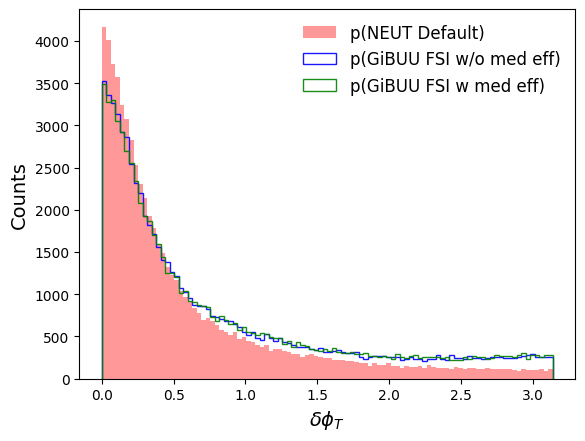

In [75]:
Efl_gibuu_w_med=E_gibuu_w_med[:]
IDfl_gibuu_w_med=ID_gibuu_w_med[:]
chargefl_gibuu_w_med=charge_gibuu_w_med[:]
Pxfl_gibuu_w_med=px_gibuu_w_med[:]
Pyfl_gibuu_w_med=py_gibuu_w_med[:]
Pzfl_gibuu_w_med=pz_gibuu_w_med[:]
Ptfl_gibuu_w_med=np.sqrt(Pxfl_gibuu_w_med**2+Pyfl_gibuu_w_med**2)
#############
Efl_gibuu_wo_med=E_gibuu_wo_med[:]
IDfl_gibuu_wo_med=ID_gibuu_wo_med[:]
chargefl_gibuu_wo_med=charge_gibuu_wo_med[:]
Pxfl_gibuu_wo_med=px_gibuu_wo_med[:]
Pyfl_gibuu_wo_med=py_gibuu_wo_med[:]
Pzfl_gibuu_wo_med=pz_gibuu_wo_med[:]
Ptfl_gibuu_wo_med=np.sqrt(Pxfl_gibuu_wo_med**2+Pyfl_gibuu_wo_med**2)




# ################## delta pt for GiBUU###############################

# dptx_wo_med=Pxfl_gibuu_wo_med+Pxfl_gibuu_wo_med[:,0]
# dpty_wo_med=Pyfl_gibuu_wo_med+Pyfl_gibuu_wo_med[:,0]
# Efn_gibuu_wo_med=Efl_gibuu_wo_med-0.935
# dphi_wo_med=(-Pxfl_gibuu_wo_med*Pxfl_gibuu_wo_med[:,0]-Pyfl_gibuu_wo_med*Pyfl_gibuu_wo_med[:,0])/((Ptfl_gibuu_wo_med)*(np.sqrt(Pxfl_gibuu_wo_med[:,0]*Pxfl_gibuu_wo_med[:,0]+Pyfl_gibuu_wo_med[:,0]*Pyfl_gibuu_wo_med[:,0])))

# # # # # # print([len(i) for i in px_list])
# # # # # # print(invalid_index)
# # # # print(min(len_Efn_gibuu))
# leading_proton_index_gibuu_wo_med=[int(np.argmax(i)) for i in Efl_gibuu_wo_med[(IDfl_gibuu_wo_med==1) & (chargefl_gibuu_wo_med==1) & (Efl_gibuu_wo_med>0)] if len(i) > 0]
# dphi_wo_med=ak.Array([i for i in dphi_wo_med[(IDfl_gibuu_wo_med==1) & (chargefl_gibuu_wo_med==1)& (Efl_gibuu_wo_med>0)] if len(i) > 0])

# # # leading_proton_index_gibuu,Efn_gibuu[(ID_gibuu_mod==1) & (charge_gibuu_mod==1)]
# # dptx_wo_med=ak.Array([i for i in dptx_wo_med[(IDfl_gibuu_wo_med==1) & (chargefl_gibuu_wo_med==1) & (Efl_gibuu_wo_med>0)] if len(i) > 0])
# # dpty_wo_med=ak.Array([i for i  in dpty_wo_med[(IDfl_gibuu_wo_med==1) & (chargefl_gibuu_wo_med==1)& (Efl_gibuu_wo_med>0)] if len(i) > 0])
# # # # len(dptx),len(Efn_gibuu[(ID_gibuu_mod==1) & (charge_gibuu_mod==1)])
# # # # dptx,Efn_gibuu[(ID_gibuu_mod==1) & (charge_gibuu_mod==1)]
# # # len_E_gibuu=[len(i) for i in Efn_gibuu[(ID_gibuu_mod==1) & (charge_gibuu_mod==1)]if len(i) > 0]    
# same_shape = ak.num(dptx_wo_med, axis=1) == ak.num(dpty_wo_med, axis=1)
# print(np.unique(same_shape))
# dphi_mod_wo_med=[]
# counter = 0
# for i in leading_proton_index_gibuu_wo_med:
#     if len(dphi_wo_med[counter]) > 0 :
#         #print(i,dptx[counter][i])
#         dphi_mod_wo_med.append(dphi_wo_med[counter][i])

#     counter += 1
# # # leading_proton_index_gibuu , len(leading_proton_index_gibuu)    
# # Efn_gibuu[(ID_gibuu_mod[i]==1) & (charge_gibuu_mod[i]==1)]
# dphi_mod_wo_med=ak.Array(dphi_mod_wo_med)
# dphif_gibuu_wo_med=dphi_mod_wo_med
# print(len(dphif_gibuu_wo_med),"dphif_gibuu_wo_med")



# ################## delta pt for NEUT###############################

# ##########################################################
px_neut=px[idx1]
py_neut=py[idx1]
Ef_neut=E[idx1]-0.935-0.035
chasef_neut=chase[idx1]
pdg_neut=pdg[idx1]
pt_neut=np.sqrt(px_neut**2+py_neut**2)
dptx_neut=px_neut+px_neut[:,2]
dpty_neut=py_neut+py_neut[:,2]
dphi_neut=(-px_neut*px_neut[:,2]-py_neut*py_neut[:,2])/((pt_neut)*(np.sqrt(px_neut[:,2]*px_neut[:,2]+py_neut[:,2]*py_neut[:,2])))

len(px),len(dptx_neut)
leading_proton_index_neut=[int(np.argmax(i)) for i in Ef_neut[(pdg_neut==2212) & (chase_neut==1) & (Ef_neut>0)] if len(i) > 0]
print(len(leading_proton_index_neut))
len(leading_proton_index_neut)
masked_dphi = dphi_neut[(pdg_neut == 2212) & (chase_neut == 1)& (Ef_neut>0)]

# # Filter out empty sublists (length > 0)
dphi_neut = masked_dphi[ak.num(masked_dphi, axis=1) > 0]
# same_shape = ak.num(dphi_neut, axis=1) == ak.num(dphi_neut, axis=1)
# print(np.unique(same_shape))
# print(len(dalpha_neut))
dphi_mod_neut=[]
counter = 0
for i in leading_proton_index_neut:
    if len(dphi_neut[counter]) > 0 :
        #print(i,dptx[counter][i])
        dphi_mod_neut.append(dphi_neut[counter][i])

    counter += 1
dphi_mod_neut=ak.Array(dphi_mod_neut)
dphif_neut=dphi_mod_neut
print(len(dphif_neut),"neut")

# # ########################## with medium eff###############
# # ################## delta pt for GiBUU###############################
dptx_w_med=Pxfl_gibuu_w_med+Pxfl_gibuu_w_med[:,0]
dpty_w_med=Pyfl_gibuu_w_med+Pyfl_gibuu_w_med[:,0]
Efn_gibuu_w_med=Efl_gibuu_w_med-0.935
dphi_w_med=(-Pxfl_gibuu_w_med*Pxfl_gibuu_w_med[:,0]-Pyfl_gibuu_w_med*Pyfl_gibuu_w_med[:,0])/((Ptfl_gibuu_w_med)*(np.sqrt(Pxfl_gibuu_w_med[:,0]*Pxfl_gibuu_w_med[:,0]+Pyfl_gibuu_w_med[:,0]*Pyfl_gibuu_w_med[:,0])))

# ##Efn_gibuu_w_med=np.sqrt(px_gibuu_mod_w_med**2+py_gibuu_mod_w_med**2+pz_gibuu_mod_w_med**2+0.938**2)-0.938
# # # # # # print([len(i) for i in px_list])
# # # # # # print(invalid_index)
# # # # print(min(len_Efn_gibuu))
leading_proton_index_gibuu_w_med=[int(np.argmax(i)) for i in Efn_gibuu_w_med[idx2][:,2:][(IDfl_gibuu_w_med[idx2][:,2:]==1) & (chargefl_gibuu_w_med[idx2][:,2:]==1)&(Efn_gibuu_w_med[idx2][:,2:]>0)] if len(i) > 0]
dphi_w_med=ak.Array([i for i in dphi_w_med[idx2][:,2:][(IDfl_gibuu_w_med[idx2][:,2:]==1) & (chargefl_gibuu_w_med[idx2][:,2:]==1)&(Efn_gibuu_w_med[idx2][:,2:]>0)] if len(i) > 0])

same_shape = ak.num(dptx_w_med, axis=1) == ak.num(dpty_w_med, axis=1)
print(np.unique(same_shape))
# print(min(len_E_gibuu))
dphi_mod_w_med=[]
counter = 0
for i in leading_proton_index_gibuu_w_med:
    if len(dphi_w_med[counter]) > 0 :
        #print(i,dptx[counter][i])
        dphi_mod_w_med.append(dphi_w_med[counter][i])

    counter += 1
# # leading_proton_index_gibuu , len(leading_proton_index_gibuu)    
# Efn_gibuu[(ID_gibuu_mod[i]==1) & (charge_gibuu_mod[i]==1)]
dphi_mod_w_med=ak.Array(dphi_mod_w_med)
dphif_gibuu_w_med=dphi_mod_w_med
print(len(dphif_gibuu_w_med),"dphif_gibuu_w_med")


#################################[idx2]
dptx_wo_med=Pxfl_gibuu_wo_med+Pxfl_gibuu_wo_med[:,0]
dpty_wo_med=Pyfl_gibuu_wo_med+Pyfl_gibuu_wo_med[:,0]
Efn_gibuu_wo_med=Efl_gibuu_wo_med-0.935
dphi_wo_med=(-Pxfl_gibuu_wo_med*Pxfl_gibuu_wo_med[:,0]-Pyfl_gibuu_wo_med*Pyfl_gibuu_wo_med[:,0])/((Ptfl_gibuu_wo_med)*(np.sqrt(Pxfl_gibuu_wo_med[:,0]*Pxfl_gibuu_wo_med[:,0]+Pyfl_gibuu_wo_med[:,0]*Pyfl_gibuu_wo_med[:,0])))

# ##Efn_gibuu_w_med=np.sqrt(px_gibuu_mod_w_med**2+py_gibuu_mod_w_med**2+pz_gibuu_mod_w_med**2+0.938**2)-0.938
# # # # # # print([len(i) for i in px_list])
# # # # # # print(invalid_index)
# # # # print(min(len_Efn_gibuu))
leading_proton_index_gibuu_wo_med=[int(np.argmax(i)) for i in Efn_gibuu_wo_med[idx][:,2:][(IDfl_gibuu_wo_med[idx][:,2:]==1) & (chargefl_gibuu_wo_med[idx][:,2:]==1)&(Efn_gibuu_wo_med[idx][:,2:]>0)] if len(i) > 0]
dphi_wo_med=ak.Array([i for i in dphi_wo_med[idx][:,2:][(IDfl_gibuu_wo_med[idx][:,2:]==1) & (chargefl_gibuu_wo_med[idx][:,2:]==1)&(Efn_gibuu_wo_med[idx][:,2:]>0)] if len(i) > 0])

same_shape = ak.num(dptx_wo_med, axis=1) == ak.num(dpty_wo_med, axis=1)
print(np.unique(same_shape))
# print(min(len_E_gibuu))
dphi_mod_wo_med=[]
counter = 0
for i in leading_proton_index_gibuu_wo_med:
    if len(dphi_wo_med[counter]) > 0 :
        #print(i,dptx[counter][i])
        dphi_mod_wo_med.append(dphi_wo_med[counter][i])

    counter += 1
# # leading_proton_index_gibuu , len(leading_proton_index_gibuu)    
# Efn_gibuu[(ID_gibuu_mod[i]==1) & (charge_gibuu_mod[i]==1)]
dphi_mod_wo_med=ak.Array(dphi_mod_wo_med)
dphif_gibuu_wo_med=dphi_mod_wo_med
print(len(dphif_gibuu_wo_med),"dphif_gibuu_w_med")
#################################

plt.hist(np.arccos(dphif_neut),color="red",bins=100,alpha=0.4,label="p(NEUT Default)",range=(0.,np.pi))
plt.hist(np.arccos(dphif_gibuu_wo_med),color="blue",bins=100,alpha=0.9,histtype='step',label="p(GiBUU FSI w/o med eff)",range=(0.,np.pi))
plt.hist(np.arccos(dphif_gibuu_w_med),color="green",bins=100,alpha=0.9,histtype='step',label="p(GiBUU FSI w med eff)",range=(0.,np.pi))

plt.legend(fontsize=12,framealpha=0.0)
plt.xlabel(r"$\delta \phi_T$",fontsize=14)
plt.ylabel(r"Counts",fontsize=14)
# plt.savefig("jg_plots_300725/leading_proton_deltaphit.png")


